# plot_traduit_out.b2us

In [1]:
import numpy as np
import re
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon 
%matplotlib notebook

files=['traduit.out.b2us.target',   # unstructured ASDEX file   (index_0)
       'traduit.out.b2us.standard', # structured ASDEX file     (index_1)
       'traduit.out.b2us_ITER',     # unstructured ITER file    (index_2)   
       'tiara.122408_4_b2us',       # unstructured ITER file    (index_3)
      ]
selected_file_index = 2
vector_type = {
    'Vx': 'nVx', 'vxX': float, 'vxY': float, 'vxPsi':float,                 # Vx
    'vxBx': float, 'vxBy': float, 'vxFfbz': float,   
    'cv': 'nCi', 'cvVxP1': int, 'cvVxP2': int, 'cvX': float, 'cvY': float,  # cv
    'psi': float, 'bp': float, 'bt': float, 'cflags': int,
    'cvReg': int, 'cvFt': int,              
    'fc': 'nFc', 'fcVx1': int, 'fcVx2': int, 'fcLbl': int, 'fcReg': int,    # fc
    'fcAligned':int,               
    'ft': 'nFt', 'ftCvP1': int, 'ftCvP2': int, 'ftFcP1': int, 'ftFcP2': int,# ft
    'ftReg': int,                
    'fs': 'nFs', 'fsFcP1': int, 'fsFcP2': int, 'fsPsi': float,              # fs
    'Xpoint': int, 
    'cvOMP': 'ncvOMP', 'cvIMP': 'ncvIMP', 'fcOMP': 'nfcOMP', 'fcIMP': 'nfcIMP',
}
with open(os.path.join(os.path.expanduser('~/Downloads'),files[selected_file_index]), 'r') as file:
    lines=file.readlines()
for i in range(0, len(lines)):
    if lines[i].startswith("*cf:"):
        line_without_arrays = re.sub(r'\([:,s]*([1-9]*)\)', r'\1', lines[i]).strip()
        line = re.split(r'[ ,]+', line_without_arrays)
        data_type = line[1]
        if data_type in ('int', 'real'):
            if data_type == 'real':
                dtype = 'float'
            else:
                dtype = 'int'
            num_elements = int(line[2])
            if num_elements > len(line)-3: # array of values e.g. nCmxVx,nCmxFc,
                array_name = line[3]
                array_size = line[2]
                exec( f"{array_name} = np.empty(({array_size}), dtype={dtype})")
                j = 0
                while j < num_elements:
                    i += 1
                    values = np.fromstring(lines[i],dtype=dtype, sep=' ')
                    exec(f"{array_name}[{j}:{j+values.size}] = values")
                    j += values.size              
            else: # singletons, read next line only
                if num_elements == 0 : # empty next line
                    exec(line[var+3] + '= 0')
                else:
                    i += 1
                    values = re.findall(r'\d+', lines[i])
                    for var in range(len(values)):
                        exec(line[var+3] + '=' + values[var])
                    
        elif data_type in vector_type:
            exec(f'vector_size = {vector_type[data_type]}')
            exec(f'{data_type} = np.empty({vector_size}, dtype=int)')
            for vector_name in line[2:]:
                exec(f'{vector_name} = np.empty({vector_size},'
                     f' dtype={vector_type[vector_name].__name__})')
            for j in range(vector_size):
                lhs_tuple_str = ', '.join([_+'[j]' for _ in line[1:]])
                exec(f"({lhs_tuple_str}) = np.fromstring(lines[i+1+j],"
                      " dtype=float, sep=' ')")
            i += 1 + vector_size
        else:
            print(f"Warning: Unhandled {data_type}")
#print(nCi,nFc,nVx,nCg,nFs,nFt,isClassicalGrid)

# Plot of nodes vxX and vxY

<IPython.core.display.Javascript object>


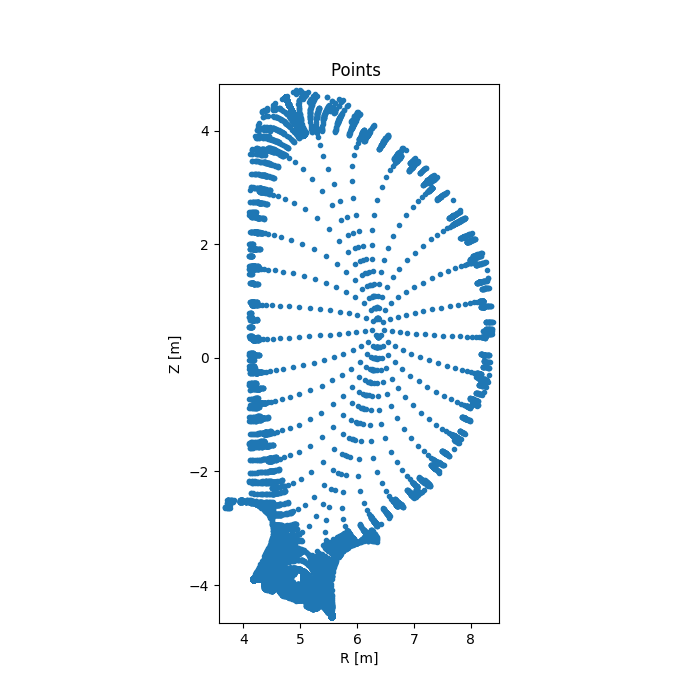

In [2]:
fig1 = plt.figure(figsize=(7, 7)) 
ax = fig1.add_subplot(111, aspect='equal')

plt.plot(vxX, vxY, '.')
    
ax.set_xlim((min(vxX)-0.1, max(vxX)+0.1)) 
ax.set_ylim((min(vxY)-0.1, max(vxY)+0.1))
plt.xlabel('R [m]')
plt.ylabel('Z [m]')
plt.title('Points ')
plt.show()

<IPython.core.display.Javascript object>


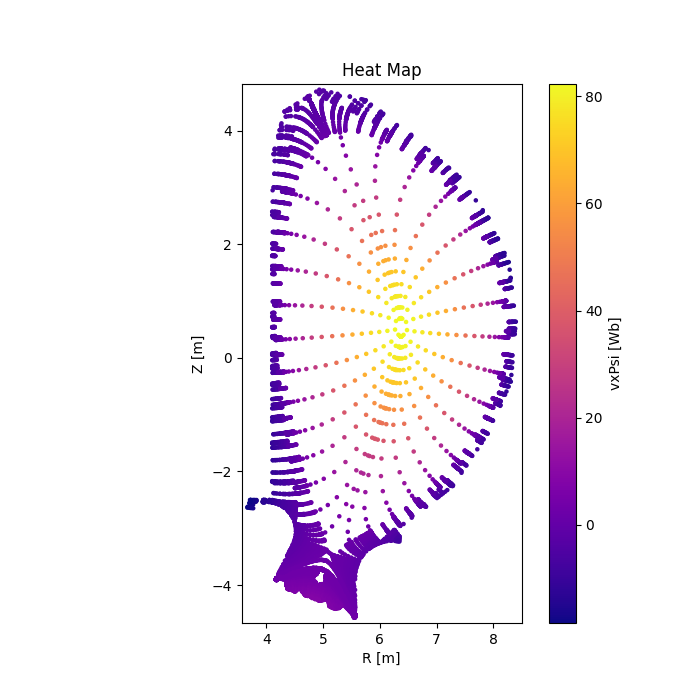

In [3]:
fig1 = plt.figure(figsize=(7, 7))
ax = fig1.add_subplot(111, aspect='equal')

# Create a scatter plot with color mapping based on vxPsi values
sc = plt.scatter(vxX, vxY, c=vxPsi, cmap='plasma', marker='.', s=20)

ax.set_xlim((min(vxX)-0.1, max(vxX)+0.1))
ax.set_ylim((min(vxY)-0.1, max(vxY)+0.1))
plt.xlabel('R [m]')
plt.ylabel('Z [m]')
plt.title('Heat Map')
plt.colorbar(sc, label='vxPsi [Wb]')

plt.show()

# Plot of cells

<IPython.core.display.Javascript object>


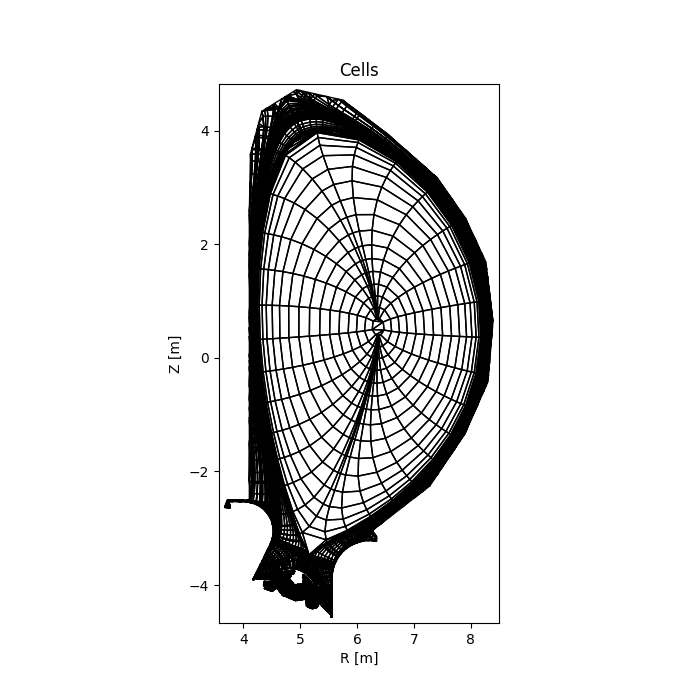

In [4]:
fig2 = plt.figure(figsize=(7, 7)) 
ax = fig2.add_subplot(111, aspect='equal')

for i in range(nCi):
#     print(cvVxP1[i], cvVxP2[i])
    cvVx_start = cvVxP1[i] - 1
    number_of_vertices = cvVxP2[i]
    cell_vertices = []
    for j in range(number_of_vertices):
        vertex_number = cvVx[cvVx_start+j] - 1
        cell_vertices.append([vxX[vertex_number], vxY[vertex_number]])
#         print(i, vertex_number, vxX[vertex_number], vxY[vertex_number])
    ax.add_patch(Polygon(cell_vertices, closed=True,fill=False))
    
ax.set_xlim((min(vxX)-0.1, max(vxX)+0.1)) 
ax.set_ylim((min(vxY)-0.1, max(vxY)+0.1))
plt.xlabel('R [m]')
plt.ylabel('Z [m]')
plt.title('Cells')
# fig2.savefig('Cells.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

# Plot of faces

<IPython.core.display.Javascript object>


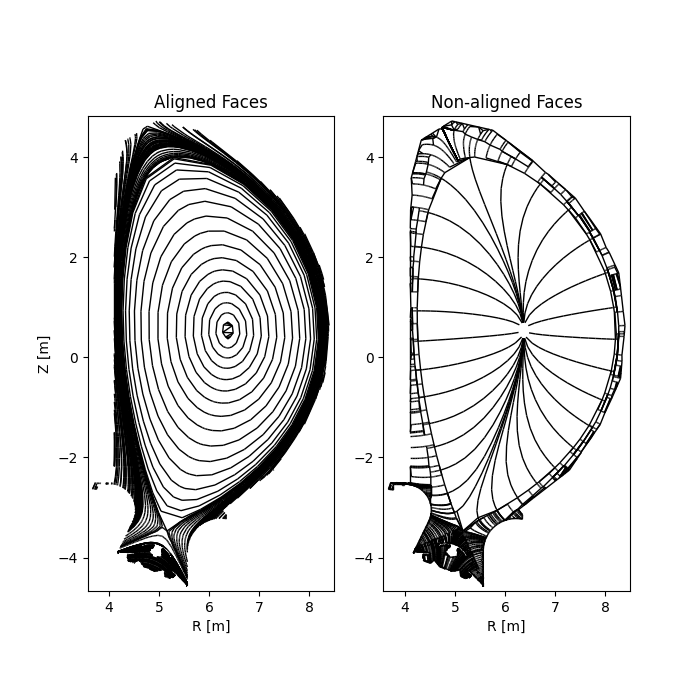

In [5]:
fig3, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 7))

# Aligned Faces
ax1.set_aspect('equal')
for i in range(nFc):
    if fcAligned[i] == 1:
        fcVx_first_point = fcVx1[i] - 1
        fcVx_second_point = fcVx2[i] - 1

        first_point = [vxX[fcVx_first_point], vxY[fcVx_first_point]]
        second_point = [vxX[fcVx_second_point], vxY[fcVx_second_point]]
        face_points = np.array([first_point, second_point])
        ax1.add_patch(Polygon(face_points, closed=False, fill=False))

ax1.set_xlim((min(vxX)-0.1, max(vxX)+0.1))
ax1.set_ylim((min(vxY)-0.1, max(vxY)+0.1))
ax1.set_xlabel('R [m]')
ax1.set_ylabel('Z [m]')
ax1.set_title('Aligned Faces')

# Non-aligned Faces
ax2.set_aspect('equal')
for i in range(nFc):
    if fcAligned[i] == 0:
        fcVx_first_point = fcVx1[i] - 1
        fcVx_second_point = fcVx2[i] - 1

        first_point = [vxX[fcVx_first_point], vxY[fcVx_first_point]]
        second_point = [vxX[fcVx_second_point], vxY[fcVx_second_point]]
        face_points = np.array([first_point, second_point])
        ax2.add_patch(Polygon(face_points, closed=False, fill=False))

ax2.set_xlim((min(vxX)-0.1, max(vxX)+0.1))
ax2.set_ylim((min(vxY)-0.1, max(vxY)+0.1))
ax2.set_xlabel('R [m]')
ax2.set_title('Non-aligned Faces')
# fig3.savefig('faces.pdf', format='pdf', dpi=300, bbox_inches='tight')

plt.show()

# Plot of flux tube

In [6]:
# Using cells data
if 'nFt' in locals() and 'ftCvP1' in locals() and 'ftCvP2' in locals() and \
    'ftCv' in locals() and 'cvVxP1' in locals() and 'cvVxP2' in locals() and \
    'cvVx' in locals() and 'vxX' in locals() and 'vxY' in locals():    

    fig5 = plt.figure(figsize=(7, 7)) 
    ax = fig5.add_subplot(111, aspect='equal')
    for i in range(nFt):
        ftCv_start = ftCvP1[i] - 1
        number_of_cells = ftCvP2[i]
        color = plt.cm.jet(i / nFt)
        for j in range(number_of_cells):
            cell_number = ftCv[ftCv_start+j] - 1
            cvVx_start = cvVxP1[cell_number] - 1 
            number_of_vertices = cvVxP2[cell_number] 
            cell_vertices = []
            for k in range(number_of_vertices):
                vertex_number = cvVx[cvVx_start+k] - 1
                cell_vertices.append([vxX[vertex_number], vxY[vertex_number]])

            ax.add_patch(Polygon(cell_vertices, closed=True, fill=False, \
            edgecolor=color))

    ax.set_xlim((min(vxX)-0.1, max(vxX)+0.1)) 
    ax.set_ylim((min(vxY)-0.1, max(vxY)+0.1))
    plt.xlabel('R [m]')
    plt.ylabel('Z [m]')
    plt.title('Flux tube-cells')
    plt.show()
else:
    print('Warning: Required data is missing for plot of flux_tube_cells.')

In [7]:
# Using faces data
if 'nFt' in locals() and 'ftFcP1' in locals() and 'ftFcP2' in locals() \
    and 'ftFc' in locals() and 'fcVx1' in locals() and 'fcVx2' in locals() \
    and 'vxX' in locals() and 'vxY' in locals():      

    fig6 = plt.figure(figsize=(7, 7))
    ax = fig6.add_subplot(111, aspect='equal')

    for i in range(nFt):
        ftFc_start = ftFcP1[i] - 1
        number_of_faces_flux_tube = ftFcP2[i]
        color = plt.cm.jet(i / nFt)

        for j in range(number_of_faces_flux_tube):
            face_number = ftFc[ftFc_start + j] - 1
            fcVx_first_point = fcVx1[face_number] - 1
            fcVx_second_point = fcVx2[face_number] - 1
            first_point = [vxX[fcVx_first_point], vxY[fcVx_first_point]]
            second_point = [vxX[fcVx_second_point], vxY[fcVx_second_point]]
            face_points = np.array([first_point, second_point])

            ax.add_patch(Polygon(face_points, closed=False, fill=False,
                edgecolor=color))

    ax.set_xlim((min(vxX) - 0.1, max(vxX) + 0.1))
    ax.set_ylim((min(vxY) - 0.1, max(vxY) + 0.1))
    plt.xlabel('R [m]')
    plt.ylabel('Z [m]')
    plt.title('Flux tube-faces')
    plt.show()
else:
    print("Warning: Required data is missing for plot of flux_tube_faces.")

# Plot of flux surface

<IPython.core.display.Javascript object>


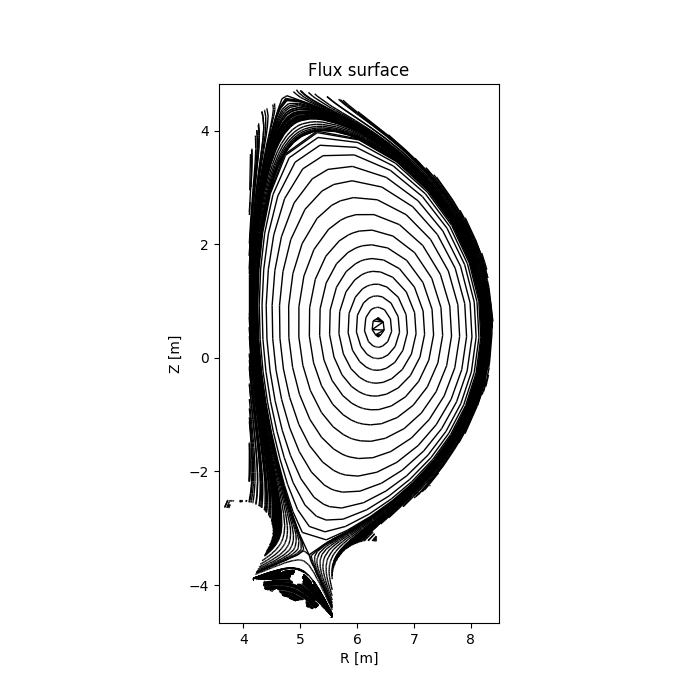

In [8]:
fig6 = plt.figure(figsize=(7, 7)) 
ax = fig6.add_subplot(111, aspect='equal')

for i in range(nFs):
#     print(fsFcP1[i], fsFcP2[i])
    fsFc_start = fsFcP1[i] - 1
    number_of_faces = fsFcP2[i]

    for j in range(number_of_faces):
        face_number = fsFc[fsFc_start+j] - 1
        fcVx_first_point = fcVx1[face_number] - 1
        fcVx_second_point = fcVx2[face_number] - 1
        first_point=[vxX[fcVx_first_point],vxY[fcVx_first_point]]
        second_point=[vxX[fcVx_second_point],vxY[fcVx_second_point]]
        face_points = np.array([first_point, second_point])
        ax.add_patch(Polygon(face_points, closed=False,fill=False))

ax.set_xlim((min(vxX)-0.1, max(vxX)+0.1)) 
ax.set_ylim((min(vxY)-0.1, max(vxY)+0.1))
plt.xlabel('R [m]')
plt.ylabel('Z [m]')
plt.title('Flux surface')
plt.show()        

<IPython.core.display.Javascript object>


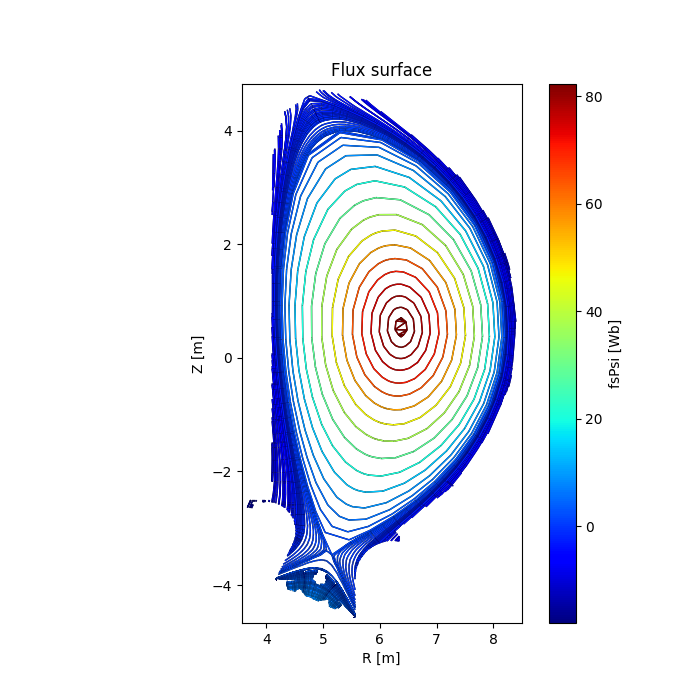

In [9]:
fig7 = plt.figure(figsize=(7, 7))
ax = fig7.add_subplot(111, aspect='equal')

# Calculate the minimum and maximum values of fsPsi
fsPsi_min = np.min(fsPsi)
fsPsi_max = np.max(fsPsi)

for i in range(nFs):
#     print(fsFcP1[i], fsFcP2[i])
    fsFc_start = fsFcP1[i] - 1
    number_of_faces = fsFcP2[i]
#     print(number_of_faces)

    for j in range(number_of_faces):
        face_number = fsFc[fsFc_start+j] - 1
        fcVx_first_point = fcVx1[face_number] - 1
        fcVx_second_point = fcVx2[face_number] - 1
        first_point=[vxX[fcVx_first_point],vxY[fcVx_first_point]]
        second_point=[vxX[fcVx_second_point],vxY[fcVx_second_point]]
        face_points = np.array([first_point, second_point])
        ax.add_patch(Polygon(face_points, closed=False,fill=False))
        
        # Calculate the color based on fsPsi value
        fs_value = fsPsi[i]
        normalized_value = (fs_value - fsPsi_min) / (fsPsi_max - fsPsi_min)
        color = plt.cm.jet(normalized_value)

        ax.add_patch(Polygon(face_points, closed=False, fill=False, edgecolor=color))

ax.set_xlim((min(vxX) - 0.1, max(vxX) + 0.1))
ax.set_ylim((min(vxY) - 0.1, max(vxY) + 0.1))
plt.xlabel('R [m]')
plt.ylabel('Z [m]')
plt.title('Flux surface')

# Create a colorbar to show the mapping of colors to fsPsi values
norm = plt.Normalize(vmin=fsPsi_min, vmax=fsPsi_max)
sm = plt.cm.ScalarMappable(cmap=plt.cm.jet, norm=norm)
sm.set_array([])  # Set an empty array to avoid warning
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('fsPsi [Wb]')

plt.show()

In [10]:
filename = 'DivGeo_file.tpl'
with open(filename, 'w') as f:
    for i in range(nFc):
        fcVx_first_point = fcVx1[i] - 1
        fcVx_second_point = fcVx2[i] - 1

        first_point = [vxX[fcVx_first_point], vxY[fcVx_first_point]]
        second_point = [vxX[fcVx_second_point], vxY[fcVx_second_point]]
        face_points = np.array([first_point, second_point])

        np.savetxt(f, face_points, fmt='%.8f', delimiter='    ')
        f.write('\n')